In [1]:
import os
import nibabel as nb 
import nitools as nt 
import EFC_learningfMRI.globals as gl
from EFC_learningfMRI.betas import RegInfo
import matplotlib.pyplot as plt
import numpy as np
from EFC_learningfMRI.util import get_trained_and_untrained

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
def fit_pc1(data):

    C, V = data.shape

    theta = []
    for c in range(0, C, 2):
        r1       = data[c]
        r2       = data[c+1]
        R        = np.c_[r1, r2].T
        R        = R[:, ~np.isnan(R).any(axis=0)]
        G        = R @ R.T
        theta.append(0.5 * np.atan2(2*G[0, 1], G[0, 0] - G[1, 1]))

    return np.array(theta)


def axial_mean(theta):
    # mean of axis orientations (mod pi): double the angles, circular-mean, halve
    return 0.5 * np.arctan2(np.mean(np.sin(2*theta)), np.mean(np.cos(2*theta)))

In [3]:
glm           = 2
sn            = 107
fname         = 'contrast.dscalar.nii'
cifti         = nb.load(os.path.join(gl.baseDir, f'glm{glm}', f'subj{sn}', fname))
contrasts     = nt.volume_from_cifti(cifti)
mask          = nb.load(os.path.join(gl.baseDir, gl.roiDir, f'subj{sn}', 'ROI.L.M1.nii'))
coords        = nt.get_mask_coords(mask)
contrasts_roi = nt.sample_image(contrasts, coords[0], coords[1], coords[2], interpolation=0).T
rep1          = contrasts_roi[::2]                                                              
rep2          = contrasts_roi[1::2]

In [4]:
contrasts_roi.shape
theta = fit_pc1(contrasts_roi)

In [5]:
reginfo = RegInfo(sn, glm)
chordID = reginfo.condition_unique.loc[::2, 0]
session = reginfo.condition_unique.loc[::2, 1]
trained   = np.array(get_trained_and_untrained(sn)[:4])

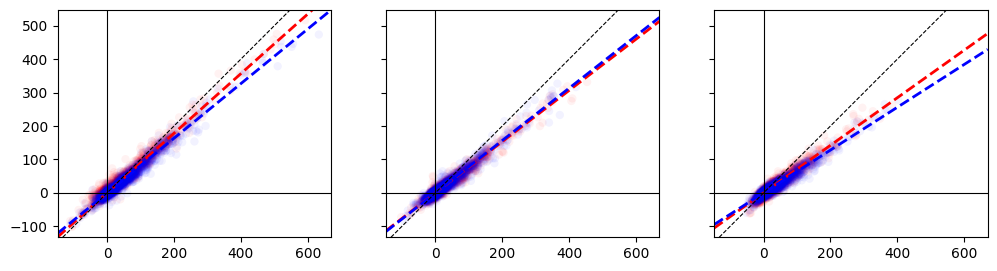

In [6]:
sessions = ['sess03', 'sess09', 'sess23']

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 12))

for s, sess in enumerate(sessions):
    ax = axs[s]

    x     = rep1[(session==sess) & (chordID.isin(trained))]
    y     = rep2[(session==sess) & (chordID.isin(trained))]
    slope = theta[(session==sess) & (chordID.isin(trained))]
    ax.scatter(x, y, color='r', alpha=.05, edgecolor='none')
    ax.axline((0, 0), slope=np.tan(axial_mean(slope)), lw=2, ls='--', color='r')

    x     = rep1[(session==sess) & (~chordID.isin(trained))]
    y     = rep2[(session==sess) & (~chordID.isin(trained))]
    slope = theta[(session==sess) & (~chordID.isin(trained))]
    ax.scatter(x, y, color='b', alpha=.05, edgecolor='none')
    ax.axline((0, 0), slope=np.tan(axial_mean(slope)), lw=2, ls='--', color='b')

    ax.axline((0, 0), slope=1, lw=.8, ls='--', color='k')
    ax.axhline(0, lw=.8, color='k')
    ax.axvline(0, lw=.8, color='k')

    ax.set_aspect('equal')

plt.show()

In [7]:
np.tan(np.deg2rad(45))

np.float64(0.9999999999999999)

In [10]:
reginfo.cond_vec.sort()

In [11]:
reginfo.cond_vec

array(['1,0,1', '1,0,1', '1,0,1', '1,0,1', '1,0,1', '1,0,1', '1,0,1',
       '1,0,1', '1,0,1', '1,0,1', '1,0,2', '1,0,2', '1,0,2', '1,0,2',
       '1,0,2', '1,0,2', '1,0,2', '1,0,2', '1,0,2', '1,0,2', '1,1,1',
       '1,1,1', '1,1,1', '1,1,1', '1,1,1', '1,1,1', '1,1,1', '1,1,1',
       '1,1,1', '1,1,1', '1,1,2', '1,1,2', '1,1,2', '1,1,2', '1,1,2',
       '1,1,2', '1,1,2', '1,1,2', '1,1,2', '1,1,2', '1,2,1', '1,2,1',
       '1,2,1', '1,2,1', '1,2,1', '1,2,1', '1,2,1', '1,2,1', '1,2,1',
       '1,2,1', '1,2,2', '1,2,2', '1,2,2', '1,2,2', '1,2,2', '1,2,2',
       '1,2,2', '1,2,2', '1,2,2', '1,2,2', '1,3,1', '1,3,1', '1,3,1',
       '1,3,1', '1,3,1', '1,3,1', '1,3,1', '1,3,1', '1,3,1', '1,3,1',
       '1,3,2', '1,3,2', '1,3,2', '1,3,2', '1,3,2', '1,3,2', '1,3,2',
       '1,3,2', '1,3,2', '1,3,2', '1,4,1', '1,4,1', '1,4,1', '1,4,1',
       '1,4,1', '1,4,1', '1,4,1', '1,4,1', '1,4,1', '1,4,1', '1,4,2',
       '1,4,2', '1,4,2', '1,4,2', '1,4,2', '1,4,2', '1,4,2', '1,4,2',
       '1,4,2', '1,4